# Model Prediktif Mesin Bor (BOR-003) — Hybrid DNN-SVM

Pipeline: sensor -> DNN (feature extractor) -> SVM (classifier), dengan SMOTE untuk menangani class imbalance, serta SHAP & LIME untuk explainability. Struktur mengikuti `induksi_model.ipynb` / `forging_model.ipynb` yang sudah divalidasi.

Dataset: `dataset-mesin-bor-training-6000.csv` (6.000 baris) berisi 6 sensor — arus, daya aktif, suhu, dan getaran 3 sumbu (X, Y, Z).

Catatan: dataset mesin bor sudah seimbang (3.000 `normal` : 3.000 `fault`), sehingga SMOTE praktis tidak menambah sampel sintetis. Langkah ini tetap dipertahankan agar pipeline identik dengan mesin lain — bila di kemudian hari data lapangan yang masuk tidak seimbang, penanganannya sudah tersedia. ADASYN tidak dipakai dengan alasan yang sama seperti mesin Induksi dan Forging: kelas minoritas terpisah cukup jauh pada sensor getaran sehingga perhitungan rasio kepadatan tetangga berisiko gagal.

In [1]:
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [2]:
raw = pd.read_csv("dataset-mesin-bor-training-6000.csv")

# Nama kolom asli memakai label tampilan berbahasa Indonesia beserta satuannya.
# Diseragamkan ke snake_case agar konsisten dengan model mesin lain (Induksi
# memakai `current_a`, `temp_c`; Forging memakai `vx`, `vy`, `vz`) sekaligus
# aman dipakai sebagai key JSON payload sensor di backend.
COLUMN_RENAME = {
    "Arus (A)": "current_a",
    "Daya Aktif (W)": "active_power_w",
    "Suhu (°C)": "temp_c",
    "Getaran Sumbu X (mm/s)": "vx",
    "Getaran Sumbu Y (mm/s)": "vy",
    "Getaran Sumbu Z (mm/s)": "vz",
    "Label": "status",
}
data = raw.rename(columns=COLUMN_RENAME)

print(f"Shape: {data.shape}")
data.head()

Shape: (6000, 7)


,current_a,active_power_w,temp_c,vx,vy,vz,status
0,0.794,152.6,34.4,15.976,8.012,47.006,normal
1,0.918,185.1,34.5,17.820,4.159,35.931,normal
2,0.984,201.0,34.8,14.996,2.397,37.160,normal
3,0.819,159.6,34.9,16.085,5.951,36.923,normal
4,0.854,169.7,34.8,15.175,7.749,39.779,normal


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   current_a       6000 non-null   float64
 1   active_power_w  6000 non-null   float64
 2   temp_c          6000 non-null   float64
 3   vx              6000 non-null   float64
 4   vy              6000 non-null   float64
 5   vz              6000 non-null   float64
 6   status          6000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 328.3 KB


In [4]:
data.describe()

,current_a,active_power_w,temp_c,vx,vy,vz
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,0.846152,166.964734,43.361237,15.832448,9.378394,37.334767
std,0.027307,7.372054,5.024950,1.586400,14.111488,5.831665
min,0.794000,152.600000,30.300000,9.199000,0.061000,0.987000
25%,0.828000,161.877750,39.026500,15.220750,4.309750,36.359750
50%,0.839000,165.368000,43.310000,16.028500,5.771000,38.713000
75%,0.859000,170.984750,47.230500,16.715250,7.423000,40.484000
max,0.991000,203.400000,52.500000,23.573000,65.493000,57.074000


In [5]:
label_columns = ["status"]
feature_columns = ["current_a", "active_power_w", "temp_c", "vx", "vy", "vz"]

TARGETS = {
    "status": {
        # Nilai label pada dataset: "normal" / "fault".
        # Dipetakan ke penamaan kelas yang sama dengan mesin Induksi & Forging.
        "label_map": {"normal": 0, "fault": 1},
        "class_names": ["Ok", "Fault"],
    },
}

print("Feature columns:", feature_columns)
print(f"Total features: {len(feature_columns)}")
print("\nClass distribution per target:")
for target in label_columns:
    print(f"  {target}: {data[target].value_counts().to_dict()}")

Feature columns: ['current_a', 'active_power_w', 'temp_c', 'vx', 'vy', 'vz']
Total features: 6

Class distribution per target:
  status: {'normal': 3000, 'fault': 3000}


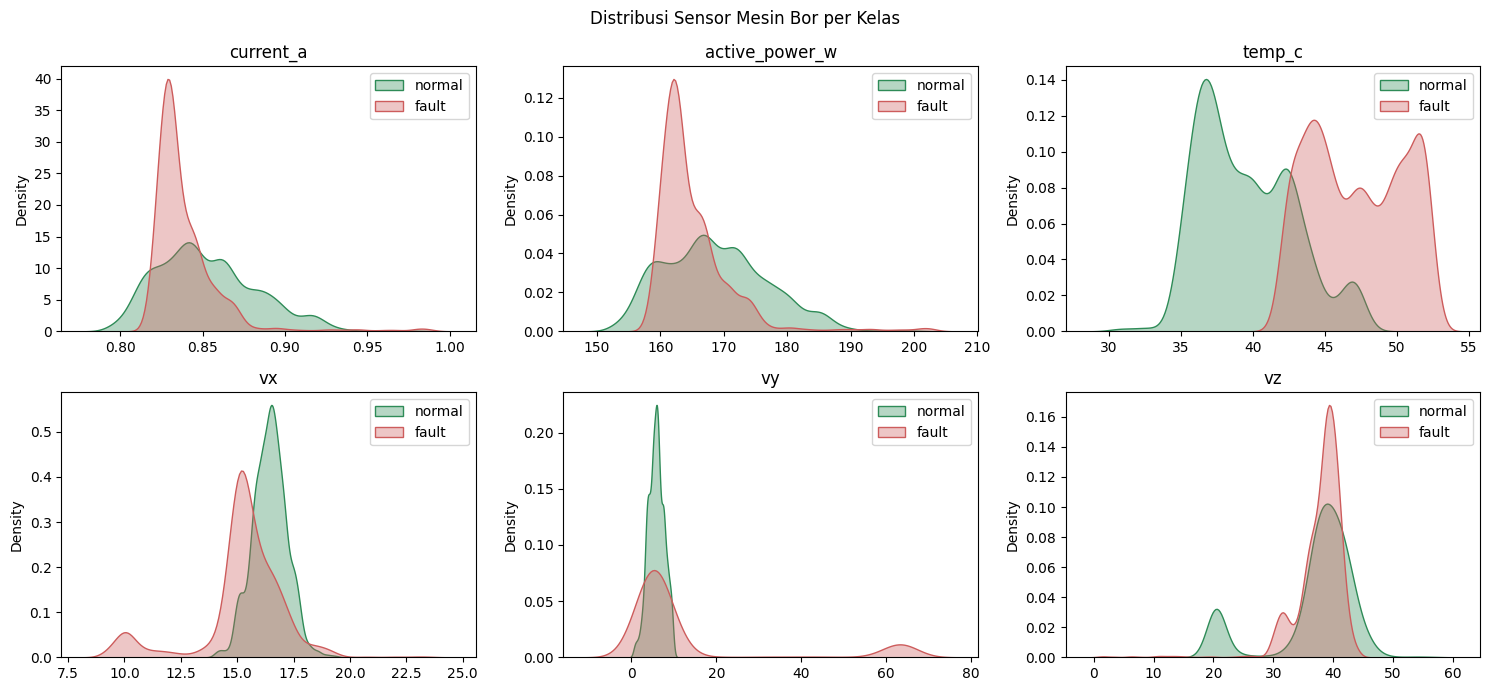

In [6]:
# Sebaran tiap sensor per kelas — untuk melihat sensor mana yang paling
# memisahkan kondisi normal dan fault.
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), feature_columns):
    for label, color in [("normal", "seagreen"), ("fault", "indianred")]:
        sns.kdeplot(
            data.loc[data["status"] == label, col],
            ax=ax, label=label, color=color, fill=True, alpha=0.35,
        )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend()
fig.suptitle("Distribusi Sensor Mesin Bor per Kelas")
plt.tight_layout()
plt.show()


  MODEL: STATUS

Train : {0: 1920, 1: 1920}
Val   : {0: 480, 1: 480}
Test  : {0: 600, 1: 600}
After SMOTE: {0: 1920, 1: 1920}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_features (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5229 - loss: 0.6873 - val_accuracy: 0.8573 - val_loss: 0.6570
Epoch 2/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7216 - loss: 0.6175 - val_accuracy: 0.9260 - val_loss: 0.5216
Epoch 3/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8266 - loss: 0.4829 - val_accuracy: 0.9354 - val_loss: 0.3588
Epoch 4/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8659 - loss: 0.3780 - val_accuracy: 0.9333 - val_loss: 0.2775
Epoch 5/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8753 - loss: 0.3280 - val_accuracy: 0.9365 - val_loss: 0.2341
Epoch 6/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8893 - loss: 0.2838 - val_accuracy: 0.9396 - val_loss: 0.2133
Epoch 7/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8917 - loss: 0.2718 - val_accuracy: 0.9365 - val_loss: 0.2039
Epoch 8/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9036 - loss: 0.2539 - val_accuracy: 0.9396 - v

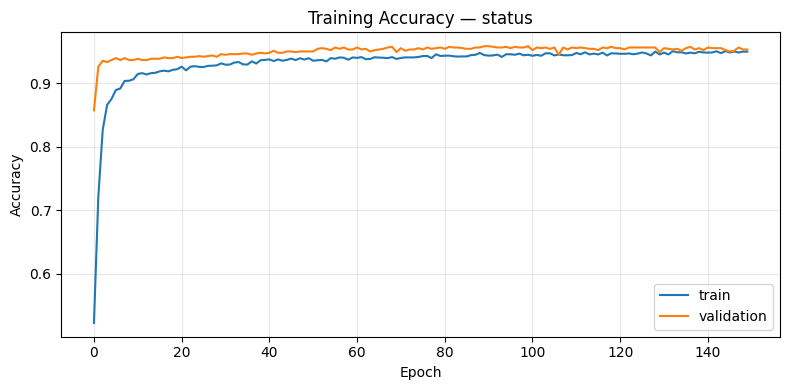


--- Metrics ---
  accuracy: 0.9575
  balanced_accuracy: 0.9575
  f1_fault: 0.9579
  roc_auc: 0.9955
              precision    recall  f1-score   support

          Ok       0.97      0.95      0.96       600
       Fault       0.95      0.97      0.96       600

    accuracy                           0.96      1200
   macro avg       0.96      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200



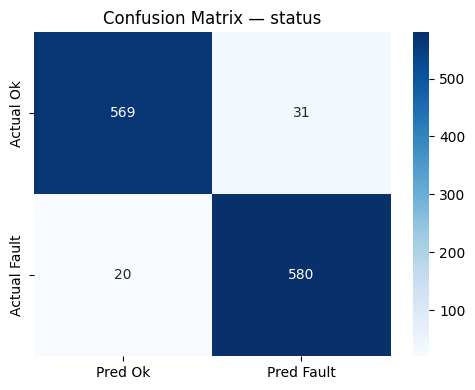

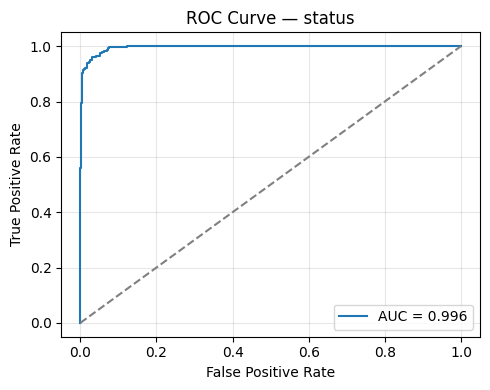

  0%|          | 0/50 [00:00<?, ?it/s]

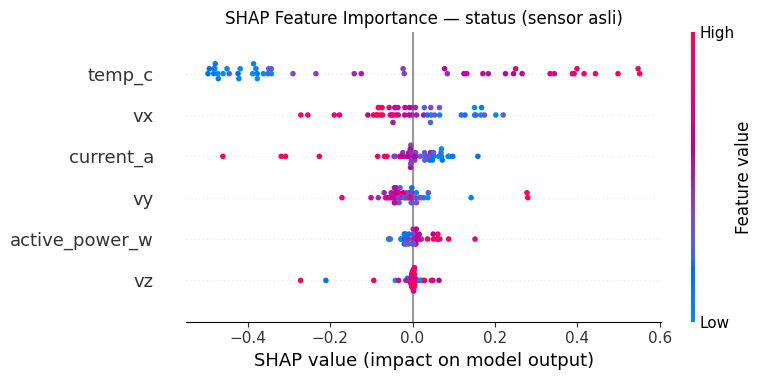

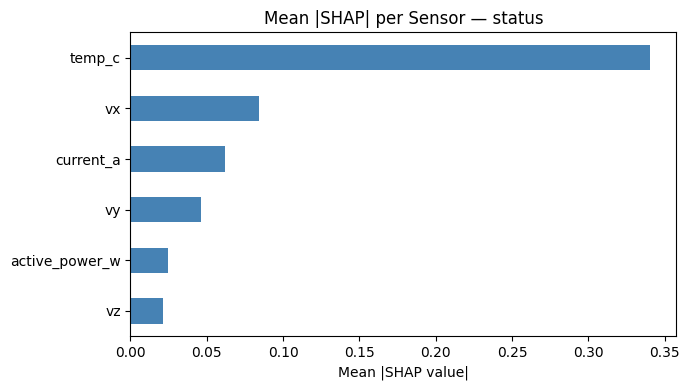

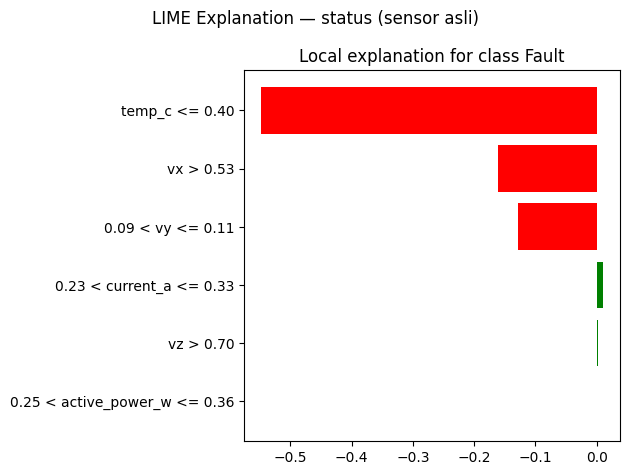

Saved: models/hybrid_model_status.pkl


In [7]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

all_metrics = {}

for target_column, config in TARGETS.items():
    print(f"\n{'='*60}")
    print(f"  MODEL: {target_column.upper()}")
    print(f"{'='*60}\n")

    label_map = config["label_map"]
    class_names = config["class_names"]

    X = data[feature_columns].copy()
    y = data[target_column].map(label_map)

    # --- Split ---
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    X_train_raw, X_val_raw, y_train, y_val = train_test_split(
        X_train_raw, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
    )

    print(f"Train : {y_train.value_counts().to_dict()}")
    print(f"Val   : {y_val.value_counts().to_dict()}")
    print(f"Test  : {y_test.value_counts().to_dict()}")

    # --- Scale ---
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_val   = scaler.transform(X_val_raw)
    X_test  = scaler.transform(X_test_raw)

    # --- SMOTE ---
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f"After SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

    # --- DNN ---
    tf.random.set_seed(RANDOM_STATE)
    model = Sequential([
        Input(shape=(X_train_res.shape[1],)),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(16, activation="relu", name="latent_features"),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    model.summary()

    early_stop = EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True
    )
    history = model.fit(
        X_train_res, y_train_res,
        epochs=150,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        shuffle=True,
        verbose=1,
    )

    # Training history
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="validation")
    plt.title(f"Training Accuracy — {target_column}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Feature extractor ---
    feature_extractor = tf.keras.Model(
        inputs=model.inputs,
        outputs=model.get_layer("latent_features").output,
    )
    train_features_res = feature_extractor.predict(X_train_res, verbose=0)
    val_features       = feature_extractor.predict(X_val, verbose=0)
    test_features      = feature_extractor.predict(X_test, verbose=0)

    # --- SVM ---
    svm = SVC(
        kernel="rbf", C=10, gamma="scale",
        class_weight="balanced", probability=True,
        random_state=RANDOM_STATE,
    )
    svm.fit(train_features_res, y_train_res)

    # --- Evaluation ---
    pred   = svm.predict(test_features)
    y_prob = svm.predict_proba(test_features)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "f1_fault": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }
    all_metrics[target_column] = metrics

    print("\n--- Metrics ---")
    for name, value in metrics.items():
        print(f"  {name}: {value:.4f}")
    print(classification_report(y_test, pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=[f"Pred {c}" for c in class_names],
        yticklabels=[f"Actual {c}" for c in class_names],
    )
    plt.title(f"Confusion Matrix — {target_column}")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"ROC Curve — {target_column}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- SHAP (pipeline end-to-end: sensor asli -> DNN -> SVM) ---
    def pipeline_predict_proba(X_sensor):
        latent = feature_extractor.predict(X_sensor, verbose=0)
        return svm.predict_proba(latent)

    shap_background = shap.sample(X_train, 100, random_state=RANDOM_STATE)
    shap_explainer = shap.KernelExplainer(
        pipeline_predict_proba,
        shap_background,
    )
    shap_values = shap_explainer.shap_values(X_test[:50])
    # shap_values shape: (n_samples, n_features, n_classes) -> ambil kelas fault (index 1)
    sv_arr = np.array(shap_values)
    if sv_arr.ndim == 3:
        sv_fault = sv_arr[:, :, 1]   # (n_samples, n_features) untuk kelas fault
    elif isinstance(shap_values, list):
        sv_fault = np.array(shap_values[1])
    else:
        sv_fault = sv_arr
    shap.summary_plot(sv_fault, X_test[:50], feature_names=feature_columns, show=False)
    plt.title(f"SHAP Feature Importance — {target_column} (sensor asli)")
    plt.tight_layout()
    plt.show()

    # Bar plot rata-rata |SHAP| per sensor
    mean_shap = np.abs(sv_fault).mean(axis=0)
    shap_df = pd.Series(mean_shap, index=feature_columns).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(7, 4))
    shap_df.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Mean |SHAP| per Sensor — {target_column}")
    ax.set_xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()

    # --- LIME (pipeline end-to-end: sensor asli -> DNN -> SVM) ---
    lime_explainer = LimeTabularExplainer(
        X_train,
        feature_names=feature_columns,
        class_names=class_names,
        mode="classification",
        discretize_continuous=True,
        random_state=RANDOM_STATE,
    )
    lime_exp = lime_explainer.explain_instance(
        X_test[0], pipeline_predict_proba, num_features=len(feature_columns)
    )
    fig = lime_exp.as_pyplot_figure()
    fig.suptitle(f"LIME Explanation — {target_column} (sensor asli)")
    plt.tight_layout()
    plt.show()

    # --- Save ---
    model.save(models_dir / f"dnn_{target_column}.keras")
    feature_extractor.save(models_dir / f"dnn_extractor_{target_column}.keras")
    joblib.dump(
        {
            "scaler": scaler,
            "svm": svm,
            "feature_columns": feature_columns,
            "target_column": target_column,
            "label_mapping": label_map,
            "class_names": class_names,
            "metrics": metrics,
        },
        models_dir / f"hybrid_model_{target_column}.pkl",
    )
    print(f"Saved: models/hybrid_model_{target_column}.pkl")


  RINGKASAN METRICS — STATUS
  Accuracy        : 0.9575
  Balanced Acc    : 0.9575
  F1 Fault        : 0.9579
  ROC-AUC         : 0.9955


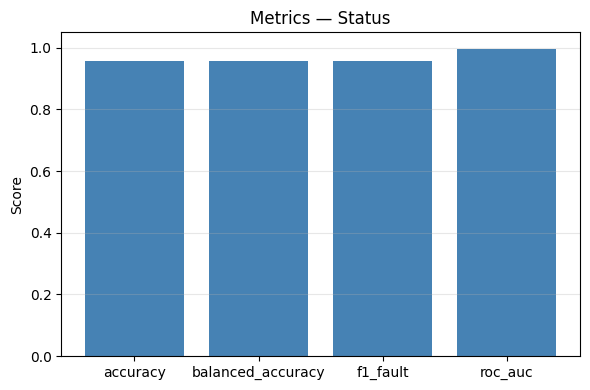

In [8]:
target_column = "status"
metrics = all_metrics[target_column]

print("\n" + "="*60)
print("  RINGKASAN METRICS — STATUS")
print("="*60)

print(f"  Accuracy        : {metrics['accuracy']:.4f}")
print(f"  Balanced Acc    : {metrics['balanced_accuracy']:.4f}")
print(f"  F1 Fault        : {metrics['f1_fault']:.4f}")
print(f"  ROC-AUC         : {metrics['roc_auc']:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(metrics.keys(), metrics.values(), color="steelblue")
ax.set_title("Metrics — Status")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Uji Coba Inferensi

Memuat kembali artefak yang tersimpan di `models/` dan menjalankan prediksi pada beberapa sampel sensor — memastikan bundle siap dipakai backend (`app/predictors/`).

In [9]:
bundle = joblib.load(models_dir / "hybrid_model_status.pkl")
extractor = tf.keras.models.load_model(models_dir / "dnn_extractor_status.keras")

def predict_bor(sample: dict):
    """Prediksi satu pembacaan sensor mesin bor (dict key = feature_columns)."""
    x = np.array([[sample[c] for c in bundle["feature_columns"]]], dtype=float)
    latent = extractor.predict(bundle["scaler"].transform(x), verbose=0)
    proba = bundle["svm"].predict_proba(latent)[0]
    fault_prob = float(proba[1])
    return {
        "prediction": bundle["class_names"][int(fault_prob >= 0.5)],
        "fault_probability": round(fault_prob, 4),
        "health_score": round(1 - fault_prob, 4),
    }

# Ambil satu contoh nyata dari tiap kelas
samples = {
    "normal": data[data["status"] == "normal"].iloc[0],
    "fault":  data[data["status"] == "fault"].iloc[0],
}
for actual, row in samples.items():
    sample = {c: float(row[c]) for c in feature_columns}
    print(f"Actual: {actual:7s} -> {predict_bor(sample)}")

Actual: normal  -> {'prediction': 'Ok', 'fault_probability': 0.0142, 'health_score': 0.9858}
Actual: fault   -> {'prediction': 'Fault', 'fault_probability': 1.0, 'health_score': 0.0}
